# Step 2: Load Data and Conduct Auto-EDA for Analysis of Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

file_path = "/Users/brandonacosta/Documents/GitHub/text-analytics-spring-2026/assignment_2/data/raw/IMDB Dataset.csv"
df = pd.read_csv(file_path)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print("number of rows:", df.shape[0])
print("number of columns:", df.shape[1])

number of rows: 50000
number of columns: 2


In [4]:
print("column names:")
print(df.columns.tolist())

column names:
['review', 'sentiment']


In [5]:
print("\ndata types:")
print(df.dtypes)


data types:
review       object
sentiment    object
dtype: object


In [6]:
missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values

,missing_count,missing_percent
review,0,0.0
sentiment,0,0.0


In [7]:
target_distribution = pd.DataFrame({
    "count": df["sentiment"].value_counts(),
    "percent": df["sentiment"].value_counts(normalize=True).mul(100).round(2)
})

target_distribution

,count,percent
sentiment,,
positive,25000,50.0
negative,25000,50.0


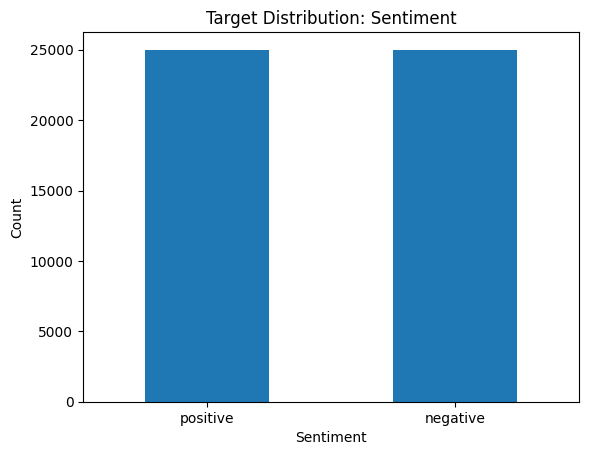

In [8]:
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Target Distribution: Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [9]:
df["char_count"] = df["review"].astype(str).str.len()
df["word_count"] = df["review"].astype(str).str.split().str.len()

length_summary = df.groupby("sentiment")[["char_count", "word_count"]].agg(["mean", "median", "std"])
length_summary.round(2)

char_count                 word_count               
                mean median      std       mean median     std
sentiment                                                     
negative     1294.06  973.0   945.89     229.46  174.0  164.95
positive     1324.80  968.0  1031.49     232.85  172.0  177.50

In [10]:
from autoviz.AutoViz_Class import AutoViz_Class

AV = AutoViz_Class()

dft = AV.AutoViz(
    filename="",
    sep=",",
    depVar="sentiment",
    dfte=df.sample(1000, random_state=42),
    header=0,
    verbose=0,
    lowess=False,
    chart_format="svg",
    max_rows_analyzed=1000,
    max_cols_analyzed=10
)

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)
Shape of your Data Set loaded: (1000, 4)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    3 Predictors classified...
        No variables removed since no ID or low-information variables found in data set
Since Number of Rows in data 1000 exceeds maximum, randomly sampling 1000 rows for EDA...

################ Binary_Classification problem #####################
    All variables classified into correct types.


,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
review,object,0.000000,100,,,No issue
char_count,int64,0.000000,78,209.000000,6230.000000,Column has 83 outliers greater than upper bound (2951.50) or lower than lower bound(-668.50). Cap them or remove them.
word_count,int64,0.000000,41,37.000000,1010.000000,"Column has 74 outliers greater than upper bound (533.00) or lower than lower bound(-123.00). Cap them or remove them., Column has a high correlation with ['char_count']. Consider dropping one of them."
sentiment,object,0.000000,0,,,Target column


Total Number of Scatter Plots = 3


[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /Users/brandonacosta/nltk_data...
[nltk_dat

All Plots done
Time to run AutoViz = 10 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


## Class Distribution and Text Analytics

In [12]:
class_counts = df["sentiment"].value_counts()
class_percent = df["sentiment"].value_counts(normalize=True).mul(100).round(2)

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percent": class_percent
})

class_distribution

,count,percent
sentiment,,
positive,25000,50.0
negative,25000,50.0


In [13]:
majority_count = class_counts.max()
minority_count = class_counts.min()
ratio = majority_count / minority_count

print(f"majority-to-minority ratio: {ratio:.2f}:1")

majority-to-minority ratio: 1.00:1


In [14]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
df["char_count"] = df["review"].astype(str).str.len()
df["word_count"] = df["review"].astype(str).str.split().str.len()

length_summary = df.groupby("sentiment")[["char_count", "word_count"]].agg(["mean", "median", "std"]).round(2)
length_summary

char_count                 word_count               
             mean    median   std       mean    median   std  
sentiment                                                     
negative    1294.06   973.0   945.89   229.46    174.0  164.95
positive    1324.80   968.0  1031.49   232.85    172.0  177.50

In [16]:
avg_word_count = df.groupby("sentiment")["word_count"].mean()

plt.figure(figsize=(6, 4))
avg_word_count.plot(kind="bar")
plt.title("Average Word Count by Class")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
import re

def simple_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-z']+", " ", text)
    return [word for word in text.split() if word]

vocab_summary = {}

for label in df["sentiment"].unique():
    tokens = []
    for review in df[df["sentiment"] == label]["review"]:
        tokens.extend(simple_tokenize(review))
    vocab_summary[label] = len(set(tokens))

pd.DataFrame.from_dict(vocab_summary, orient="index", columns=["vocabulary_size"])

,vocabulary_size
positive,87253
negative,82917


In [18]:
from sklearn.feature_extraction.text import CountVectorizer

for label in ["positive", "negative"]:
    print(f"\nTop words for {label} reviews")
    
    subset = df[df["sentiment"] == label]["review"]
    vectorizer = CountVectorizer(stop_words="english", max_features=15)
    X = vectorizer.fit_transform(subset)
    
    top_words = pd.DataFrame({
        "word": vectorizer.get_feature_names_out(),
        "frequency": X.toarray().sum(axis=0)
    }).sort_values("frequency", ascending=False)
    
    display(top_words)


Top words for positive reviews


,word,frequency
1,br,97954
2,film,42110
9,movie,37854
7,like,17714
3,good,15025
5,just,14109
4,great,12964
12,story,12934
13,time,12752
11,really,10739



Top words for negative reviews


,word,frequency
1,br,103997
8,movie,50117
3,film,37595
6,like,22458
5,just,21075
4,good,14728
0,bad,14726
14,time,12358
12,really,12355
2,don,10622


Step 3: Text Cleaning and Preprocessing

We know that we dealing with sentiment/reviews, we will following the suggested domain-appropriate cleaning for improved sentiment analysis. 

In [20]:
positive_example = df[df["sentiment"] == "positive"]["review"].iloc[0]
negative_example = df[df["sentiment"] == "negative"]["review"].iloc[0]

print("positive example BEFORE cleaning:\n")
print(positive_example)

print("\n" + "-"*80 + "\n")

print("negative example BEFORE cleaning:\n")
print(negative_example)

positive example BEFORE cleaning:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main a

Based on the examples above, we identify that we will need to remove HTML code (like the line breaks), leftover excess punctuations or abnormal spacing, keep essential punctuations (like !, ..., and ?), and any negations or contractions. 

In [22]:
import re

def clean_review(text):
    text = str(text)
    
    # remove html break tags
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)
    
    # remove repeated slashes left behind
    text = re.sub(r"/+", " ", text)
    
    # normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [23]:
df["clean_review"] = df["review"].apply(clean_review)

In [24]:
positive_row = df[df["sentiment"] == "positive"].iloc[0]
negative_row = df[df["sentiment"] == "negative"].iloc[0]

print("POSITIVE BEFORE:\n")
print(positive_row["review"])

print("\n" + "-"*80 + "\n")

print("POSITIVE AFTER:\n")
print(positive_row["clean_review"])

print("\n" + "="*80 + "\n")

print("NEGATIVE BEFORE:\n")
print(negative_row["review"])

print("\n" + "-"*80 + "\n")

print("NEGATIVE AFTER:\n")
print(negative_row["clean_review"])

POSITIVE BEFORE:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

In [25]:
#verify that no rows contain HTML data "<br"
print("reviews with <br before cleaning:", df["review"].str.contains("<br", case=False, regex=False).sum())
print("reviews with <br after cleaning:", df["clean_review"].str.contains("<br", case=False, regex=False).sum())

reviews with <br before cleaning: 29200
reviews with <br after cleaning: 0


## Step 4 & 5: Feature Engineering and Training Models
The two approaches used for feature engineering will be CountVectorizer and TFIDF. Since this is a binary model, we will use the range of 1000-5000. 

In [27]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [28]:
max_features = 3000

count_vectorizer = CountVectorizer(
    max_features=max_features,
    ngram_range=(1, 2)
)

tfidf_vectorizer = TfidfVectorizer(
    max_features=max_features,
    ngram_range=(1, 2)
)

In [29]:
feature_methods = pd.DataFrame({
    "method": ["CountVectorizer", "TF-IDF"],
    "max_features": [3000, 3000],
    "ngram_range": ["(1, 2)", "(1, 2)"]
})

feature_methods

,method,max_features,ngram_range
0,CountVectorizer,3000,"(1, 2)"
1,TF-IDF,3000,"(1, 2)"


In [30]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (40000,)
X_test: (10000,)
y_train: (40000,)
y_test: (10000,)


Now, we will test and compare two algorithms: Multinomial NB and Logistic Regression. Each will be tested using the train and test datasets for both Count Vectorizer and TFIDF. 

In [32]:
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Count train shape:", X_train_count.shape)
print("Count test shape:", X_test_count.shape)
print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

Count train shape: (40000, 3000)
Count test shape: (10000, 3000)
TF-IDF train shape: (40000, 3000)
TF-IDF test shape: (10000, 3000)


In [33]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [34]:
nb_count = MultinomialNB()
nb_count.fit(X_train_count, y_train)

y_pred_nb_count = nb_count.predict(X_test_count)

print("MultinomialNB + CountVectorizer")
print("Accuracy:", round(accuracy_score(y_test, y_pred_nb_count), 4))
print("Precision:", round(precision_score(y_test, y_pred_nb_count, pos_label="positive"), 4))
print("Recall:", round(recall_score(y_test, y_pred_nb_count, pos_label="positive"), 4))
print("F1:", round(f1_score(y_test, y_pred_nb_count, pos_label="positive"), 4))

MultinomialNB + CountVectorizer
Accuracy: 0.8272
Precision: 0.8296
Recall: 0.8236
F1: 0.8266


In [35]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

print("MultinomialNB + TF-IDF")
print("Accuracy:", round(accuracy_score(y_test, y_pred_nb_tfidf), 4))
print("Precision:", round(precision_score(y_test, y_pred_nb_tfidf, pos_label="positive"), 4))
print("Recall:", round(recall_score(y_test, y_pred_nb_tfidf, pos_label="positive"), 4))
print("F1:", round(f1_score(y_test, y_pred_nb_tfidf, pos_label="positive"), 4))

MultinomialNB + TF-IDF
Accuracy: 0.8518
Precision: 0.8425
Recall: 0.8654
F1: 0.8538


In [36]:
lr_count = LogisticRegression(max_iter=1000)
lr_count.fit(X_train_count, y_train)

y_pred_lr_count = lr_count.predict(X_test_count)

print("Logistic Regression + CountVectorizer")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr_count), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr_count, pos_label="positive"), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr_count, pos_label="positive"), 4))
print("F1:", round(f1_score(y_test, y_pred_lr_count, pos_label="positive"), 4))

Logistic Regression + CountVectorizer
Accuracy: 0.879
Precision: 0.8808
Recall: 0.8766
F1: 0.8787


In [37]:
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)

y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("Logistic Regression + TF-IDF")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr_tfidf), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr_tfidf, pos_label="positive"), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr_tfidf, pos_label="positive"), 4))
print("F1:", round(f1_score(y_test, y_pred_lr_tfidf, pos_label="positive"), 4))

Logistic Regression + TF-IDF
Accuracy: 0.8875
Precision: 0.8845
Recall: 0.8914
F1: 0.8879


In [38]:
results = pd.DataFrame({
    "model": [
        "MultinomialNB + CountVectorizer",
        "MultinomialNB + TF-IDF",
        "Logistic Regression + CountVectorizer",
        "Logistic Regression + TF-IDF"
    ],
    "accuracy": [
        accuracy_score(y_test, y_pred_nb_count),
        accuracy_score(y_test, y_pred_nb_tfidf),
        accuracy_score(y_test, y_pred_lr_count),
        accuracy_score(y_test, y_pred_lr_tfidf)
    ],
    "precision": [
        precision_score(y_test, y_pred_nb_count, pos_label="positive"),
        precision_score(y_test, y_pred_nb_tfidf, pos_label="positive"),
        precision_score(y_test, y_pred_lr_count, pos_label="positive"),
        precision_score(y_test, y_pred_lr_tfidf, pos_label="positive")
    ],
    "recall": [
        recall_score(y_test, y_pred_nb_count, pos_label="positive"),
        recall_score(y_test, y_pred_nb_tfidf, pos_label="positive"),
        recall_score(y_test, y_pred_lr_count, pos_label="positive"),
        recall_score(y_test, y_pred_lr_tfidf, pos_label="positive")
    ],
    "f1": [
        f1_score(y_test, y_pred_nb_count, pos_label="positive"),
        f1_score(y_test, y_pred_nb_tfidf, pos_label="positive"),
        f1_score(y_test, y_pred_lr_count, pos_label="positive"),
        f1_score(y_test, y_pred_lr_tfidf, pos_label="positive")
    ]
})

results = results.sort_values(by="f1", ascending=False).round(4)
results

,model,accuracy,precision,recall,f1
3,Logistic Regression + TF-IDF,0.8875,0.8845,0.8914,0.8879
2,Logistic Regression + CountVectorizer,0.8790,0.8808,0.8766,0.8787
1,MultinomialNB + TF-IDF,0.8518,0.8425,0.8654,0.8538
0,MultinomialNB + CountVectorizer,0.8272,0.8296,0.8236,0.8266


## Step 6: Analysis of Models 
Based on the f1 store, which is the balance between precision and recall, the Logistic Regression + TFIDF model has the best performance and a the highest accuracy rate amongst the 4 models. This step we will evaluate each of the 4 models further based on their classification reports and confusion matrixes. 

### Multinomial Naive Bayes + CountVectorizer Classification Report + Confusion Matrix

In [99]:
from sklearn.metrics import classification_report
%matplotlib inline
import matplotlib.pyplot as plt

print("Classification Report: MultinomialNB + CountVectorizer")
print(classification_report(y_test, y_pred_nb_count))

Classification Report: MultinomialNB + CountVectorizer
              precision    recall  f1-score   support

    negative       0.82      0.83      0.83      5000
    positive       0.83      0.82      0.83      5000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



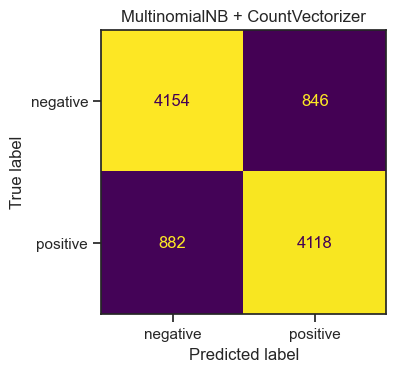

In [105]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_nb_count, labels=["negative", "positive"])

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(ax=ax, colorbar=False, values_format="d")
ax.set_title("MultinomialNB + CountVectorizer")
plt.tight_layout()
plt.show()

This is the weakest of the 4 models, with all metrics being around 0.83. False positive and false negative rate is quite high given the scope of the data, and when  compared to the other 4 models. 

### Multinomial Naive Bayes + TFIDF Classification Report + Confusion Matrix

In [87]:
print("Classification Report: MultinomialNB + TF-IDF")
print(classification_report(y_test, y_pred_nb_tfidf))

Classification Report: MultinomialNB + TF-IDF
              precision    recall  f1-score   support

    negative       0.86      0.84      0.85      5000
    positive       0.84      0.87      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



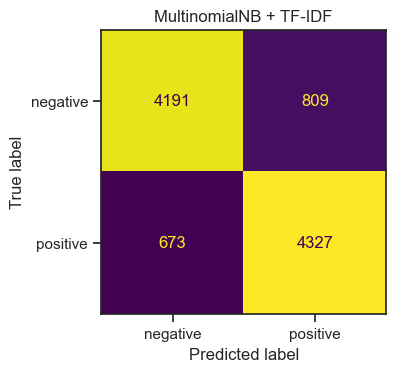

In [107]:
cm = confusion_matrix(y_test, y_pred_nb_tfidf, labels=["negative", "positive"])

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(ax=ax, colorbar=False, values_format="d")
ax.set_title("MultinomialNB + TF-IDF")
plt.tight_layout()
plt.show()

Although we see some improvements using Naive Bayes with TFIDF, the improvements are truly minimal with a slight jump in metrics to around 0.85. This is most likely due to the fact that TFIDF improves the capture of sentiment in the text, and since these are reviews, capturing emotions in the text is essential. Although the false negative rate seems to have decreased, the false positive rate remains relatively the same for this model. 

### Logistic Regression + CountVectorizer Classification Report + Confusion Matrix

In [91]:
print("Classification Report: Logistic Regression + CountVectorizer")
print(classification_report(y_test, y_pred_lr_count))

Classification Report: Logistic Regression + CountVectorizer
              precision    recall  f1-score   support

    negative       0.88      0.88      0.88      5000
    positive       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



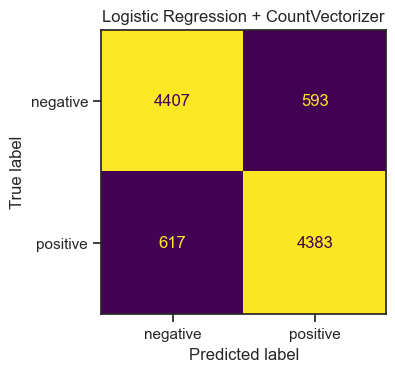

In [109]:
cm = confusion_matrix(y_test, y_pred_lr_count, labels=["negative", "positive"])

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(ax=ax, colorbar=False, values_format="d")
ax.set_title("Logistic Regression + CountVectorizer")
plt.tight_layout()
plt.show()

Switching to Logistic Regression, we definitely see an improvement in the overall improvement of the model, with metrics being around 0.88. Overall, the confusion matrix displays fewer overall errors, and improved confidence in the model. 

### Logistic Regression + TF-IDF Classification Report + Confusion Matrix

In [95]:
print("Classification Report: Logistic Regression + TF-IDF")
print(classification_report(y_test, y_pred_lr_tfidf))

Classification Report: Logistic Regression + TF-IDF
              precision    recall  f1-score   support

    negative       0.89      0.88      0.89      5000
    positive       0.88      0.89      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



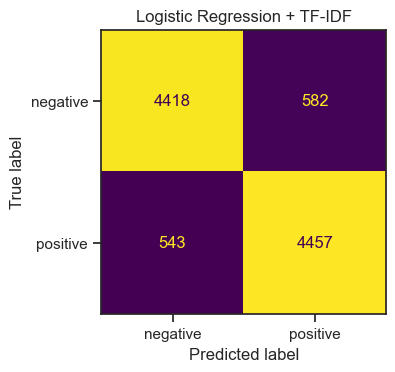

In [111]:
cm = confusion_matrix(y_test, y_pred_lr_tfidf, labels=["negative", "positive"])

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(ax=ax, colorbar=False, values_format="d")
ax.set_title("Logistic Regression + TF-IDF")
plt.tight_layout()
plt.show()

Our final and best model, Logistic Regression + TF-IDF, shows the highest precision, recall, and F1 scores, around 0.89. The confusion matrix also has the fewest overall errors, and shows a strong balance between the errors. 

### Identify Importance/Class Label 
For this dataset, I suggest that decision-makers focus on negative reviews. Moviegoers are more likely to express their negative reviews if they are truly dissatisfied with a movie. Often, negative sentiment reviews provide the most constructive feedback and can pinpoint problems that movie-producing executives and directors need to address in future projects. Although at the opposite end of the spectrum, positive reviews can highlight what the general public prefers or is more likely to watch; they are also more likely to be skewed by bias, obsessive fan behavior, and to lack any sort of constructive feedback. Prioritizing negative reviews yields the most actionable insights from this type of data. 

This would make recall the most important factor for analyzing the data. The higher the recall, the more negative reviews the model misses. A false negative in our modeling can hide important client feedback and disguise negative sentiment as a positive review. That considered, precision still matters to a similar extent, since an extremely low precision rate would mean a greater number of falsely labeled negative reviews that are actually positive. Thus, basing the decision on overall F1 scores helps us select the best model, balancing recall and precision. 

Logistic Regression and TFIDF weren't just the most accurate of the 4 models, but also balanced across all metrics, offering stable performance while achieving the strongest negative-class performance of the 4 models. 

### Sample 20-row review:

In [115]:
review_20 = pd.DataFrame({
    "review": X_test,
    "actual": y_test,
    "predicted": y_pred_lr_tfidf
})

review_20_sample = review_20.sample(20, random_state=42).copy()
review_20_sample

review                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   \
44114  This is loosely based on the ideas of the original 80's hit . It's set in the modern day as we see a base in Afghanistan get destroyed by a UAV right at the start. And that's exactly where the movie jumps the shark. UAV's aren't armed. They could be but I don't think it's ever been tried for real. We get to see the computer that has masterminded this operation, called R.I.P.L.E.Y. We are introduced to "hacker" Will Farmer (he's good at chemistry & electronics which doesn't make him a computer hacker) & his love interest, Annie) & Will's 1st attempt at hacking is not only a complete failure his IP address is also logged and Annie guessed who it was. We also meet Wills mom who works for a chemical company. Wills taking money from his neighbours bank account (Mr Massude) isn't a hack (he helped him set up the account), we then get a nod back to the original movie where they decide against playing Global Thermonuclear War & they play The Dead Code. The trace the RIPLEY office are running is NOT on Will but on Massude's pc so all the evidence they were gathering was useless against Will. Exactly why RIPLEY shut Will's machine down isn't explained (he's only playing an online game?) & also why it felt the need to have to shut down all the electricity in the entire block he lived in as well. Why a counter terrorism agency would see this as a viable target is extremely questionable. As for RIPLEY activating his mobile phone? I think not, it wasn't connected to the pc an

After reviewing a 20-row random sample of the dataset with the actual, and predicted values for our selected best model, we can directly see the strengths and weaknesses of the model. Overall, the accurately predicted values were reasonable, and based off the presence of strongly negative, direct phrasing like "boring" or "lame. Positive reviews were greatly affected by words like "must see" and "well made". Overall, of most of the reviews, I agree with the modeling. Some reviews were definitely more on the neutral end, starting positively but ending in some overall constructive feedback. All things considered, from a modeling perspective, the categorization of these reviews was accurate, and based off the overall word count of highly positive-leaning or negative-leaning reviews. 

Mistakes pop up when the pattern of the review is indirect, and is also incredibly long. The more long, nuanced, and subtly critical a review (such as those that are constructive, highlighting the positive and negative aspects of the film), the harder time the model has being accurate. This demostrates the limits of the model with complex review language, since real people reviewing films often vary in their taste, length of description, and overall bias when watching a film. 

### Five-Criteria Comparison:

In [117]:
import time
from sklearn.linear_model import LogisticRegression

timing_results = []

models_to_time = [
    ("Logistic Regression + CountVectorizer", LogisticRegression(max_iter=1000), X_train_count, X_test_count),
    ("Logistic Regression + TF-IDF", LogisticRegression(max_iter=1000), X_train_tfidf, X_test_tfidf)
]

for model_name, model, Xtr, Xte in models_to_time:
    start_time = time.time()
    model.fit(Xtr, y_train)
    _ = model.predict(Xte)
    elapsed_time = time.time() - start_time
    
    timing_results.append({
        "model": model_name,
        "speed_seconds": round(elapsed_time, 4)
    })

timing_df = pd.DataFrame(timing_results)
timing_df

,model,speed_seconds
0,Logistic Regression + CountVectorizer,4.8793
1,Logistic Regression + TF-IDF,0.3236


In [119]:
comparison_5 = pd.DataFrame({
    "model": [
        "Logistic Regression + CountVectorizer",
        "Logistic Regression + TF-IDF"
    ],
    "accuracy": [
        accuracy_score(y_test, y_pred_lr_count),
        accuracy_score(y_test, y_pred_lr_tfidf)
    ],
    "f1": [
        f1_score(y_test, y_pred_lr_count, pos_label="positive"),
        f1_score(y_test, y_pred_lr_tfidf, pos_label="positive")
    ],
    "negative_recall": [
        recall_score(y_test, y_pred_lr_count, pos_label="negative"),
        recall_score(y_test, y_pred_lr_tfidf, pos_label="negative")
    ],
    "interpretability": [
        "high",
        "high"
    ],
    "ease_of_tuning": [
        "easy",
        "easy"
    ]
})

comparison_5 = comparison_5.merge(timing_df, on="model")
comparison_5 = comparison_5[[
    "model",
    "accuracy",
    "f1",
    "speed_seconds",
    "negative_recall",
    "interpretability",
    "ease_of_tuning"
]].round(4)

comparison_5

,model,accuracy,f1,speed_seconds,negative_recall,interpretability,ease_of_tuning
0,Logistic Regression + CountVectorizer,0.8790,0.8787,4.8793,0.8814,high,easy
1,Logistic Regression + TF-IDF,0.8875,0.8879,0.3236,0.8836,high,easy


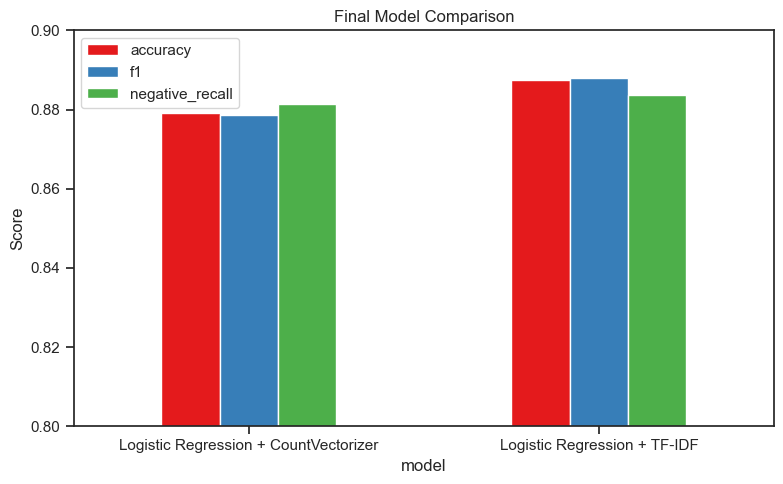

In [121]:
plot_df = comparison_5.set_index("model")[["accuracy", "f1", "negative_recall"]]

plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Final Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.80, 0.90)
plt.tight_layout()
plt.show()

In [123]:
best_model = comparison_5.sort_values(by="f1", ascending=False).iloc[0]

print("Recommended model:", best_model["model"])
print("F1 score:", best_model["f1"])
print("Negative recall:", best_model["negative_recall"])
print("Speed (seconds):", best_model["speed_seconds"])

Recommended model: Logistic Regression + TF-IDF
F1 score: 0.8879
Negative recall: 0.8836
Speed (seconds): 0.3236


Based on a comparison of the two best models, we see some overall similarities, but ultimately, we see why the Logistic Regression + TFIDF model is the best overall to choose from. Not only is accuracy higher, but the F1 score and the negative recall rate (the overall ability to capture our desired true negative reviews) demonstrate that this is the best model. Although recall between both models is very close, the overall accuracy and F1 still highlight the improvements TFIDF makes in the modeling based on its improved ability to capture sentiments. Additionally, the TF-IDF model is faster by a few seconds, making it more scalable if the training dataset were expanded to several hundred thousand reviews. Although the overall build of the models are very similar, using TFIDF is the overall better choice for the feature engineering when compared to CountVectorizer. 

## Step 7: Custom Inference

In [125]:
new_texts = [
    # 10 easy examples
    "This movie was amazing. The acting was strong, the story was engaging, and I loved the ending.",
    "One of the best films I have seen in years. Every scene felt meaningful and well made.",
    "I really enjoyed this movie. It was funny, emotional, and beautifully directed.",
    "A fantastic performance by the entire cast. I would definitely watch it again.",
    "This film was excellent from beginning to end. It kept my attention the whole time.",
    "This movie was terrible. The plot made no sense and the acting was painfully bad.",
    "I hated this film. It was boring, too long, and not worth watching.",
    "One of the worst movies I have ever seen. Nothing about it worked for me.",
    "This was a complete mess. The dialogue was awful and the story went nowhere.",
    "The movie started badly and somehow got even worse. I regret wasting my time on it.",

    # 5 tricky examples
    "The movie looked beautiful, but I honestly did not care about a single character by the end.",
    "It had some strong moments, although the second half nearly ruined the whole experience.",
    "I wanted to love this film, and parts of it were great, but overall it felt disappointing.",
    "The acting was good and the visuals were impressive, yet something about it felt empty.",
    "Sure, it was two and a half hours long and barely made sense, but at least I got a nice nap out of it.",

    # 5 slightly different context examples
    "This documentary was informative and surprisingly moving. I learned a lot and stayed interested throughout.",
    "The animated film had a simple story, but it was charming, funny, and perfect for families.",
    "The horror movie had a creepy atmosphere, though the ending was weak and predictable.",
    "This old black-and-white classic was slower than modern films, but the performances were excellent.",
    "The streaming original had an interesting premise, but it felt more like a long TV episode than a real movie."
]

In [127]:
example_types = (
    ["easy"] * 10 +
    ["tricky"] * 5 +
    ["different_context"] * 5
)

In [129]:
X_new = tfidf_vectorizer.transform(new_texts)
new_predictions = lr_tfidf.predict(X_new)

In [131]:
inference_results = pd.DataFrame({
    "example_type": example_types,
    "text": new_texts,
    "predicted_sentiment": new_predictions
})

inference_results

,example_type,text,predicted_sentiment
0,easy,"This movie was amazing. The acting was strong, the story was engaging, and I loved the ending.",positive
1,easy,One of the best films I have seen in years. Every scene felt meaningful and well made.,positive
2,easy,"I really enjoyed this movie. It was funny, emotional, and beautifully directed.",positive
3,easy,A fantastic performance by the entire cast. I would definitely watch it again.,positive
4,easy,This film was excellent from beginning to end. It kept my attention the whole time.,positive
5,easy,This movie was terrible. The plot made no sense and the acting was painfully bad.,negative
6,easy,"I hated this film. It was boring, too long, and not worth watching.",negative
7,easy,One of the worst movies I have ever seen. Nothing about it worked for me.,negative
8,easy,This was a complete mess. The dialogue was awful and the story went nowhere.,negative
9,easy,The movie started badly and somehow got even worse. I regret wasting my time on it.,negative


1. **Example 1**  
   - My label: **positive**  
   - Model prediction: **positive**  
   - Result: **agree**  
   - Notes: Very clearly positive. Strong praise for acting, story, and ending.

2. **Example 2**  
   - My label: **positive**  
   - Model prediction: **positive**  
   - Result: **agree**  
   - Notes: Straightforward positive review with strong approval.

3. **Example 3**  
   - My label: **positive**  
   - Model prediction: **positive**  
   - Result: **agree**  
   - Notes: Clear positive sentiment with words like funny, emotional, and beautifully directed.

4. **Example 4**  
   - My label: **positive**  
   - Model prediction: **positive**  
   - Result: **agree**  
   - Notes: Positive overall tone and clear recommendation to rewatch.

5. **Example 5**  
   - My label: **positive**  
   - Model prediction: **positive**  
   - Result: **agree**  
   - Notes: Very obvious positive review with strong favorable wording.

6. **Example 6**  
   - My label: **negative**  
   - Model prediction: **negative**  
   - Result: **agree**  
   - Notes: Clearly negative with direct criticism of plot and acting.

7. **Example 7**  
   - My label: **negative**  
   - Model prediction: **negative**  
   - Result: **agree**  
   - Notes: Strong direct negative sentiment with little ambiguity.

8. **Example 8**  
   - My label: **negative**  
   - Model prediction: **negative**  
   - Result: **agree**  
   - Notes: Obvious negative review with strong language like “worst.”

9. **Example 9**  
   - My label: **negative**  
   - Model prediction: **negative**  
   - Result: **agree**  
   - Notes: Clearly negative from the overall wording and tone.

10. **Example 10**  
    - My label: **negative**  
    - Model prediction: **negative**  
    - Result: **agree**  
    - Notes: Very direct negative review with no mixed sentiment.

11. **Example 11**  
    - My label: **negative**  
    - Model prediction: **negative**  
    - Result: **agree**  
    - Notes: Even though it starts with praise for the visuals, the final judgment is negative.

12. **Example 12**  
    - My label: **negative**  
    - Model prediction: **positive**  
    - Result: **disagree**  
    - Notes: I think this should be negative because the overall conclusion is that the second half nearly ruined the experience. This is an example of mixed sentiment where the model may have focused too much on the earlier positive wording.

13. **Example 13**  
    - My label: **negative**  
    - Model prediction: **positive**  
    - Result: **disagree**  
    - Notes: I think this should be negative because the phrase “overall it felt disappointing” outweighs the earlier praise. This shows that the model can struggle when positive and negative signals appear in the same review.

14. **Example 14**  
    - My label: **negative**  
    - Model prediction: **positive**  
    - Result: **disagree**  
    - Notes: I think this should be negative because the final judgment is that the film felt empty. The review contains praise for acting and visuals, but the overall emotional takeaway is negative.

15. **Example 15**  
    - My label: **negative**  
    - Model prediction: **negative**  
    - Result: **agree**  
    - Notes: This sarcastic example was still classified correctly, which is a good sign.

16. **Example 16**  
    - My label: **positive**  
    - Model prediction: **positive**  
    - Result: **agree**  
    - Notes: Clear positive review of a documentary with strong praise.

17. **Example 17**  
    - My label: **positive**  
    - Model prediction: **positive**  
    - Result: **agree**  
    - Notes: Positive overall tone despite being from a slightly different review context.

18. **Example 18**  
    - My label: **positive**  
    - Model prediction: **negative**  
    - Result: **disagree**  
    - Notes: I think this should be positive because the review mainly praises the creepy atmosphere, and the predictable ending feels more like a minor criticism than the main conclusion. This suggests the model may overreact to negative phrases near the end of a review.

19. **Example 19**  
    - My label: **positive**  
    - Model prediction: **positive**  
    - Result: **agree**  
    - Notes: Positive overall because it praises the performances, even though it mentions the slower pacing.

20. **Example 20**  
    - My label: **negative**  
    - Model prediction: **negative**  
    - Result: **agree**  
    - Notes: Negative overall because the final judgment is that it did not feel like a real movie.